In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('titanic_imputation_practice_400_rows.csv')

In [4]:
df

,Age,Fare,Family,Survived
0,NaN,3.0210,0.0,1.0
1,28.1,8.1713,1.0,0.0
2,39.1,14.9580,0.0,0.0
3,51.3,15.5955,1.0,0.0
4,26.7,NaN,0.0,0.0
...,...,...,...,...
395,23.4,42.6554,NaN,1.0
396,6.0,NaN,1.0,0.0
397,NaN,29.4149,1.0,1.0
398,28.4,15.3071,0.0,0.0


In [5]:
df.head()

,Age,Fare,Family,Survived
0,NaN,3.0210,0.0,1.0
1,28.1,8.1713,1.0,0.0
2,39.1,14.9580,0.0,0.0
3,51.3,15.5955,1.0,0.0
4,26.7,NaN,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       352 non-null    float64
 1   Fare      360 non-null    float64
 2   Family    376 non-null    float64
 3   Survived  384 non-null    float64
dtypes: float64(4)
memory usage: 12.6 KB


In [7]:
df.isnull().mean()*100

Age         12.0
Fare        10.0
Family       6.0
Survived     4.0
dtype: float64

In [8]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
x_train.shape,x_test.shape

((320, 3), (80, 3))

USING PANDAS

In [11]:
mean_age=df['Age'].mean()
median_age=df['Age'].median()

mean_fare=df['Fare'].mean()
median_fare=df['Fare'].median()

In [12]:
x_train['Age_mean']=x_train['Age'].fillna(mean_age)
x_train['Age_median']=x_train['Age'].fillna(median_age)

x_train['Fare_mean']=x_train['Fare'].fillna(mean_fare)
x_train['Fare_median']=x_train['Fare'].fillna(median_fare)

In [13]:
x_train.sample(10)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
202,45.2,35.5026,1.0,45.200000,45.2,35.5026,35.5026
175,41.6,3.0000,0.0,41.600000,41.6,3.0000,3.0000
298,41.4,37.4882,NaN,41.400000,41.4,37.4882,37.4882
345,33.2,7.2013,0.0,33.200000,33.2,7.2013,7.2013
123,10.4,26.3271,1.0,10.400000,10.4,26.3271,26.3271
48,34.8,8.9007,0.0,34.800000,34.8,8.9007,8.9007
83,22.7,18.2372,0.0,22.700000,22.7,18.2372,18.2372
302,40.5,7.3570,1.0,40.500000,40.5,7.3570,7.3570
250,NaN,94.5337,0.0,30.102273,30.7,94.5337,94.5337
200,35.0,31.7213,1.0,35.000000,35.0,31.7213,31.7213


In [14]:
# REMEMBER  after mean and median the varience of data will be srink but keep in mind dont ush shrink is now lowed


In [15]:
print('orignal value',x_train['Age'].var())
print('age after  imputaion mean',x_train['Age_mean'].var())
print('age after  imputaion mean',x_train['Age_median'].var())
print('orignal value',x_train['Fare'].var())
print('fare after  imputaion mean',x_train['Fare_mean'].var())
print('age after  imputaion mean',x_train['Fare_median'].var())

orignal value 171.44376577973992
age after  imputaion mean 155.32544248211556
age after  imputaion mean 155.3314254506269
orignal value 821.2440027722591
fare after  imputaion mean 733.7580958931425
age after  imputaion mean 741.4133006410481


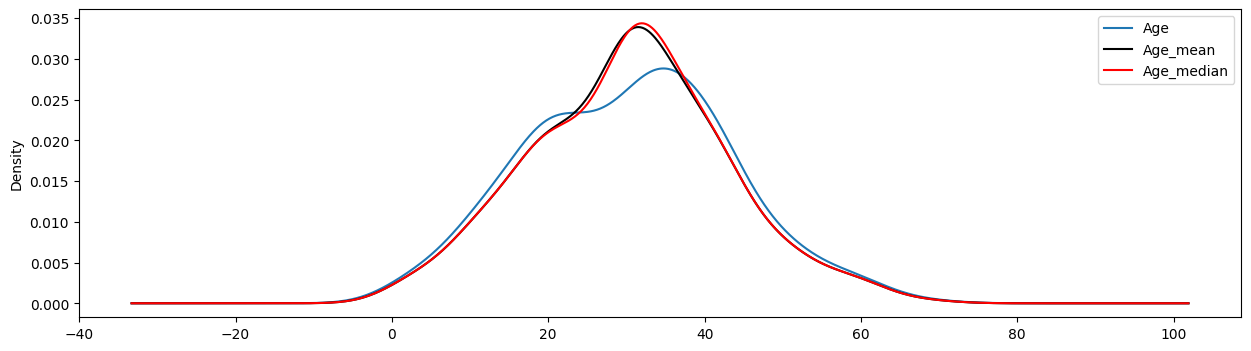

In [16]:
fig=plt.figure(figsize=(15,4))
ax=fig.add_subplot(111)

#orignal data
x_train['Age'].plot(kind='kde',ax=ax)
#mean age
x_train['Age_mean'].plot(kind='kde',ax=ax,color='black')
#median
x_train['Age_median'].plot(kind='kde',ax=ax,color='red')
plt.legend()         # so see as we knoe after the mean and medin the distribution change the plot up high

In [17]:
x_train.cov()     #find covarience  they find the realation between the data so if chnge before and afer it is not good sign

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,171.443766,-37.501496,0.111881,171.443766,171.443766,-33.696646,-35.830137
Fare,-37.501496,821.244003,0.357214,-33.845899,-34.206893,821.244003,821.244003
Family,0.111881,0.357214,0.249730,0.106543,0.100441,0.316541,0.425260
Age_mean,171.443766,-33.845899,0.106543,155.325442,155.313209,-30.398722,-32.338995
Age_median,171.443766,-34.206893,0.100441,155.313209,155.331425,-30.719714,-32.641508
Fare_mean,-33.696646,821.244003,0.316541,-30.398722,-30.719714,733.758096,734.300640
Fare_median,-35.830137,821.244003,0.425260,-32.338995,-32.641508,734.300640,741.413301


using sklearn

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
imputer1=SimpleImputer(strategy='mean')
imputer2=SimpleImputer(strategy='median')

In [20]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [21]:
# now train 
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [23]:
trf.named_transformers_['imputer1'].statistics_     # basicaly it is the mean value of age b/c in impputer one we pass age

array([30.34241379])

In [26]:
trf.named_transformers_['imputer2'].statistics_     #  it is a meadian value of fare b/c we apply imputer2 

array([15.3181])

In [27]:
x_train=trf.fit_transform(x_train)
x_test=trf.fit_transform(x_test)

In [28]:
x_train                       # now it is the value of data after imputer

array([[ 51.3       ,  15.5955    ,   1.        ],
       [ 17.3       ,  48.3902    ,   0.        ],
       [ 45.2       ,  35.5026    ,   1.        ],
       [ 30.34241379,  94.5337    ,   0.        ],
       [ 16.3       ,   3.6418    ,   0.        ],
       [ 13.3       ,  18.43      ,   1.        ],
       [ 54.7       ,  15.3181    ,   0.        ],
       [ 22.2       ,  42.479     ,          nan],
       [ 33.6       ,  15.6195    ,   1.        ],
       [ 30.34241379,  14.7616    ,   0.        ],
       [ 20.9       ,   9.7096    ,   1.        ],
       [ 27.9       ,  23.8694    ,   1.        ],
       [ 46.        ,  16.4337    ,   1.        ],
       [ 62.4       ,   6.7499    ,   1.        ],
       [ 38.8       ,  20.8738    ,   0.        ],
       [ 48.3       ,  14.3301    ,   1.        ],
       [ 43.4       ,  39.3523    ,   0.        ],
       [ 18.2       ,  15.3181    ,   1.        ],
       [ 41.9       ,  15.3181    ,   0.        ],
       [ 41.5       ,  11.5995 